<a href="https://colab.research.google.com/github/cherryjl/IT480-FA26/blob/main/Lab2_CNN_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: CNN for Image Classification (PetFinder)

**Name:** *Chris Berger and Logan Cherry*

This notebook has no starter code. Each section below tells you what to build and what questions to answer in your own words, but the code itself is yours to write. Use the CNN Fundamentals lecture and Lab 1 as your reference for syntax, not as something to copy from.

**Submission:** GitHub repo URL + this notebook's URL on Canvas.

## Setup

Clone the course repo (or your fork) to access the dataset, then import the libraries you expect to need. You will likely want `pandas`, `numpy`, `os`, image-loading tools (for example `PIL.Image`), `matplotlib`, `tensorflow`, and evaluation tools from `sklearn`. Add imports as you go, you don't need to guess all of them up front.

In [19]:
# Clone the repo to access the data (only needs to run once per Colab session)
# !git clone <your-fork-url>


In [20]:
# Your imports here
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

---
## Part A: Load and Prepare the Data

**What to do:**
1. Split the fasion_mnist dataset into train and test sets.
2. Turn the values for the X datasets into values from 0 to 1
3. Turn the values for the Y datasets into categories.



In [21]:
# Load data here
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [22]:
# Build X and y, then split into train/test here
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

---
## Part B: Build a CNN From Scratch

**What to decide, and be ready to justify:**
- How many Conv2D and MaxPooling2D layers will you use?
- How many filters at each layer, and how does that number change as you go deeper?
- What kernel size will you use, and why?
- What does your Dense classifier head look like after the Flatten layer?
- What output layer and activation fits a Dog vs. Cat task specifically? Is this the same as Lab 1's binary classification setup, or different?

Write your architecture below, then write one paragraph justifying every choice, using the conventions from lecture (filters growing with depth, 3x3 kernels, funnel-shaped Dense layers, and so on).

In [23]:
# Build your CNN model here
model = Sequential()

model.add(Conv2D(32, kernel_size = 5, activation = 'sigmoid', input_shape = (28, 28, 1)))

model.add(MaxPooling2D(pool_size = 2, strides = 2))

model.add(Conv2D(64, kernel_size = 5, activation = 'sigmoid'))

model.add(MaxPooling2D(pool_size = 2, strides = 2))

model.add(Flatten())

model.add(Dense(120, activation = 'sigmoid'))

model.add(Dense(84, activation = 'sigmoid'))

model.add(Dense(10, activation = 'sigmoid'))

In [24]:
# Compile your model here
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics=['accuracy'])

*Your architecture justification (one paragraph):*

1) We used 2 layers each of Conv2D and MaxPooling.

2) There are 32 filters at the first layer, 64 at the next, and 10 at the output.  The number of filters increases through the convolution because the map of features is decreasing through the pooling layers.  If we use more filters with less data, we will have more accurate outcomes.

3) We picked 5x5 for Conv2D and 2x2 for our pooling size because we are gonig off of the LeNet in the lecture slides, they seem like a good starting point

4) We used Dense sizes of 120, 84, 10 for the same reason as we are using the LeNet example in the lecture slides.

5) Sigmoid fits cat/dog best, while in Lab 1 we used Relu


---
## Part C: Train and Diagnose

**What to do:**
1. Train your model, saving the history.
2. Plot training vs. validation loss and accuracy.
3. Diagnose the fit: good fit, overfitting, or underfitting? Point to specific evidence from your own curve.
4. Evaluate on the test set and report accuracy.

In [25]:
# Train your model here (save the result as `history`)
history = model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6478 - loss: 0.9405 - val_accuracy: 0.7916 - val_loss: 0.5481
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8037 - loss: 0.5123 - val_accuracy: 0.8334 - val_loss: 0.4575
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8418 - loss: 0.4275 - val_accuracy: 0.8453 - val_loss: 0.4184
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8606 - loss: 0.3804 - val_accuracy: 0.8658 - val_loss: 0.3708
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8708 - loss: 0.3478 - val_accuracy: 0.8764 - val_loss: 0.3395
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8777 - loss: 0.3243 - val_accuracy: 0.8704 - val_loss: 0.3506
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8840 - loss: 0.3093 - val_accuracy: 0.8771 - val_loss: 0.3360
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8902 - loss: 0.2948 - 

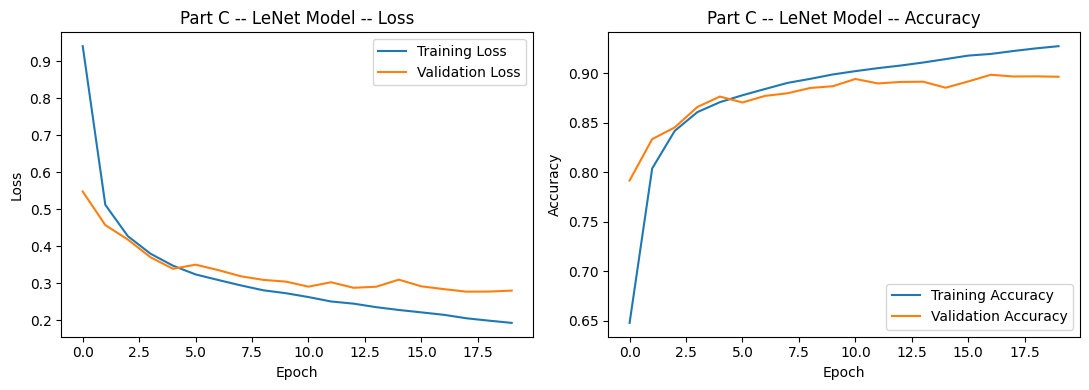

In [26]:
# Plot training vs. validation loss and accuracy here
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

plot_history(history, "Part C -- LeNet Model", show_accuracy=True)

*Your fit diagnosis, with specific evidence from your curve:*

Based on the behavior of the model with training data versus its behavior with validation data, we can say this model is overfit; training set loss consisently falls, and training set accuracy consistently rises, whereas validation set loss/accuracy either worsen or stay constant.


In [27]:
# Evaluate on the test set and report accuracy here
eval = model.evaluate(x_test, y_test)

print(f"Part 2 -- Test Loss: {eval[0]:.3f}")
print(f"Part 2 -- Test Accuracy: {eval[1]:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8931 - loss: 0.2921
Part 2 -- Test Loss: 0.292
Part 2 -- Test Accuracy: 0.893


---
## Part D: Improve the Model

Choose **one** path, based on what Part C showed you.

**If your baseline overfit:** apply Dropout, Early Stopping, or both, the same tools from Assignment 1, to your own CNN.

**If your baseline did not overfit, or you want to push accuracy further:** use Keras Tuner to search over at least 2 hyperparameters of your choosing. Keep the same test-set discipline from Assignment 1: tuning only touches training and validation data, the test set is touched once, at the end.

State which path you chose and why, before you start building it.

*Which path are you taking, and why:*

We are choosing to use both Dropout and Early Stopping because our baseline model showed clear signs of overfitting. The training loss continued to decrease and training accuracy increased, while the validation loss increased and validation accuracy stayed nearly constant. Dropout should reduce the model's dependence on specific neurons and encourage it to learn more general patterns. Early Stopping will monitor validation loss and stop training when the model no longer improves on validation data, helping prevent additional overfitting.


In [28]:
# Build your improved model here
nu_model = Sequential()

nu_model.add(Conv2D(32, kernel_size = 5, activation = 'sigmoid', input_shape = (28, 28, 1)))

nu_model.add(MaxPooling2D(pool_size = 2, strides = 2))

nu_model.add(Conv2D(64, kernel_size = 5, activation = 'sigmoid'))

nu_model.add(MaxPooling2D(pool_size = 2, strides = 2))

nu_model.add(Flatten())

nu_model.add(Dense(120, activation = 'sigmoid'))
nu_model.add(Dropout(0.5))

nu_model.add(Dense(84, activation = 'sigmoid'))
nu_model.add(Dropout(0.3))

nu_model.add(Dense(10, activation = 'sigmoid'))

nu_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.3472 - loss: 1.6993 - val_accuracy: 0.7155 - val_loss: 0.7775
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7260 - loss: 0.7331 - val_accuracy: 0.7737 - val_loss: 0.5752
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7724 - loss: 0.6048 - val_accuracy: 0.8068 - val_loss: 0.4963
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7968 - loss: 0.5398 - val_accuracy: 0.8243 - val_loss: 0.4545
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8160 - loss: 0.4977 - val_accuracy: 0.8370 - val_loss: 0.4288
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8294 - loss: 0.4664 - val_accuracy: 0.8460 - val_loss: 0.4065
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8385 - loss: 0.4420 - val_accuracy: 0.8448 - val_loss: 0.4104
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8470 - loss: 0.4207 -

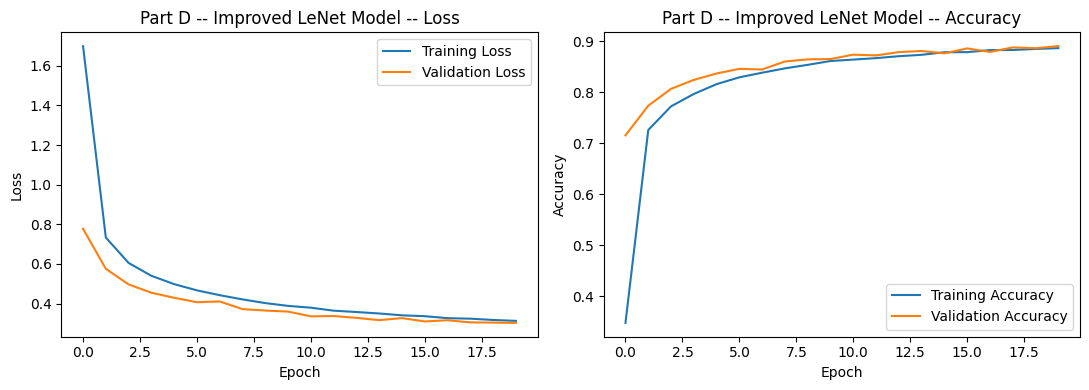

In [29]:
# Train your improved model here
early_stopping = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

improved_history = nu_model.fit(x_train,y_train,validation_split=0.2,epochs=20,batch_size=32,callbacks=[early_stopping])

plot_history(improved_history, "Part D -- Improved LeNet Model", show_accuracy=True)

In [30]:
# Evaluate your improved model and build a confusion matrix here
nu_eval = nu_model.evaluate(x_test, y_test)

print(f"Improved Test Loss: {nu_eval[0]:.3f}")
print(f"Improved Test Accuracy: {nu_eval[1]:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8873 - loss: 0.3157
Improved Test Loss: 0.316
Improved Test Accuracy: 0.887


---
## Part E: Compare and Evaluate

Fill in your own results:

| | Baseline CNN | Improved CNN |
|---|---|---|
| Test accuracy |0.898|0.900|
| Fit pattern (good/over/under) |over|good|
| What changed |-|Dropout layers between Dense layers|

Report baseline vs. improved test accuracy, fit pattern, and a confusion matrix for the improved model. Discuss which class is misclassified more often and why.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


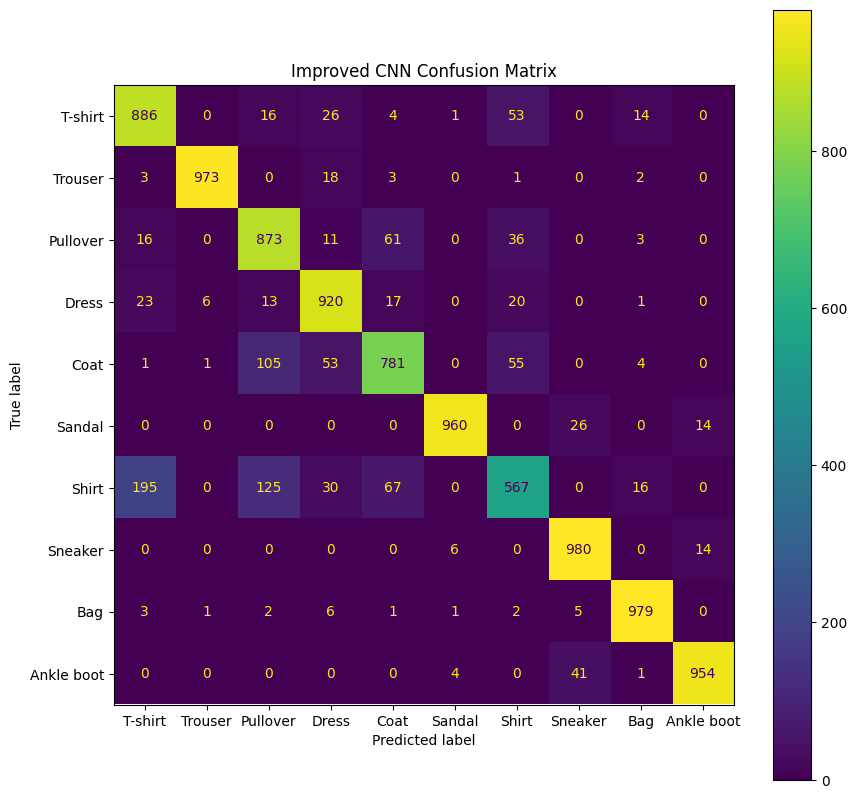

In [32]:
y_prob = nu_model.predict(x_test)

# Predicted class
y_pred = np.argmax(y_prob, axis=1)

# True class
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["T-shirt","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"])

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax)
plt.title("Improved CNN Confusion Matrix")
plt.show()

In [33]:
class_names = ["T-shirt","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]

correct_per_class = np.diag(cm)
total_per_class = cm.sum(axis=1)
errors_per_class = total_per_class - correct_per_class

for name, errors in zip(class_names, errors_per_class):
    print(f"{name}: {errors} misclassified")

worst_class = np.argmax(errors_per_class)

print("\nMost frequently misclassified class:",class_names[worst_class])

T-shirt: 114 misclassified
Trouser: 27 misclassified
Pullover: 127 misclassified
Dress: 80 misclassified
Coat: 219 misclassified
Sandal: 40 misclassified
Shirt: 433 misclassified
Sneaker: 20 misclassified
Bag: 21 misclassified
Ankle boot: 46 misclassified

Most frequently misclassified class: Shirt


*Your discussion of the confusion matrix:*

The confusion matrix shows that the model most frequently misclassified Shirts. A common incorrect prediction for this class was T-Shirts. These categories may be difficult for the CNN to distinguish because they have almost the same visual shapes and features. Looking at the misclassified images can help determine whether similarities in shape, orientation, or image detail contributed to these errors.



---
## Part F: Look at Your Mistakes

Pull 3 to 5 images your model got wrong and display them. Write 2 to 3 sentences: is there anything visually in common among the photos your model struggled with, unusual angles, poor lighting, multiple animals in frame, something else?

Number of misclassified images: 1127


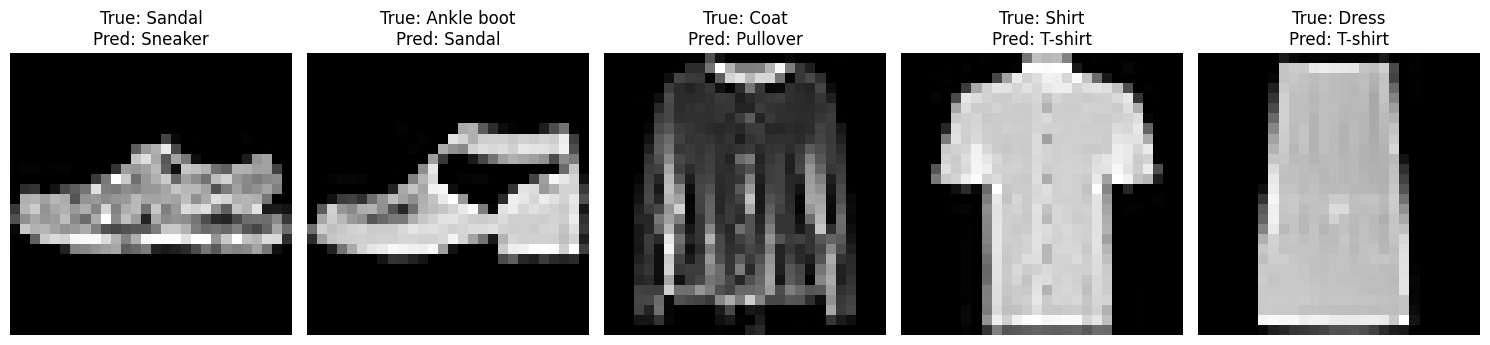

In [34]:
# Find and display misclassified images here
wrong_indices = np.where(y_pred != y_true)[0]

print("Number of misclassified images:", len(wrong_indices))

plt.figure(figsize=(15, 4))

for i, idx in enumerate(wrong_indices[:5]):

    plt.subplot(1, 5, i + 1)

    plt.imshow(x_test[idx], cmap='gray')

    true_name = class_names[y_true[idx]]
    predicted_name = class_names[y_pred[idx]]

    plt.title(
        f"True: {true_name}\n"
        f"Pred: {predicted_name}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

*Your observations about the misclassified images:*

Several of the misclassified images appear visually similar to the classes that the model predicted instead. Clothing categories such as shirts, pullovers, and coats can have similar outlines when represented as small grayscale images, making their distinguishing features difficult for the CNN to identify. Some images may also have unusual shapes or orientations that make them less similar to typical examples from their true class.



---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.